In [1]:
from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample
from src.ML.train_NN import train_model, print_NN_input_sample
#from src.predict import predict_single_text
#from src.analysis import  intra_category_similarity
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

DATA_PATH = "/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv"

In [2]:
# dataset structure:
# samples: 50 425
# categories: 4 (Househols, Electronics, Books, Clothing & Accessories)
# percentage: household: 38%, books: 24%, electronics: 21%, clothing & accessories: 17%

print("--- 1. Loading and Preparing Data ---")
df = load_data(DATA_PATH)


#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)


--- 1. Loading and Preparing Data ---
Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...



SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (555, 3000)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 3000
Matrix Format: <class 'scipy.sparse._csr.csr_matrix'>
------------------------------
First sample (first 10 TF-IDF feature values):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
------------------------------

Computed class weights:
  0: 0.6869
  1: 3.6755

Best C found via StratifiedKFold: 0.5

--- SVM CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0     0.8523    0.7426    0.7937       101
           1     0.4902    0.6579    0.5618        38

    accuracy                         0.7194       139
   macro avg     0.6712    0.7002    0.6777       139
weighted avg     0.7533    0.7194    0.7303       139



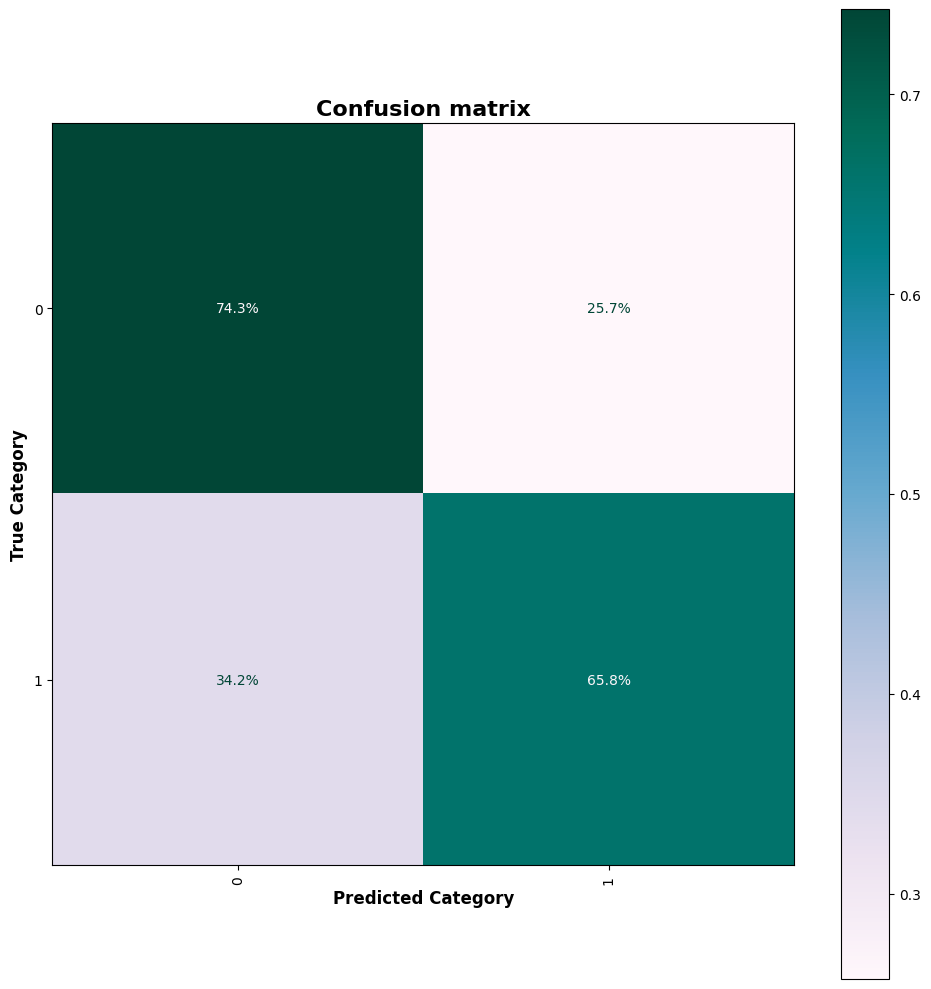

<Figure size 640x480 with 0 Axes>

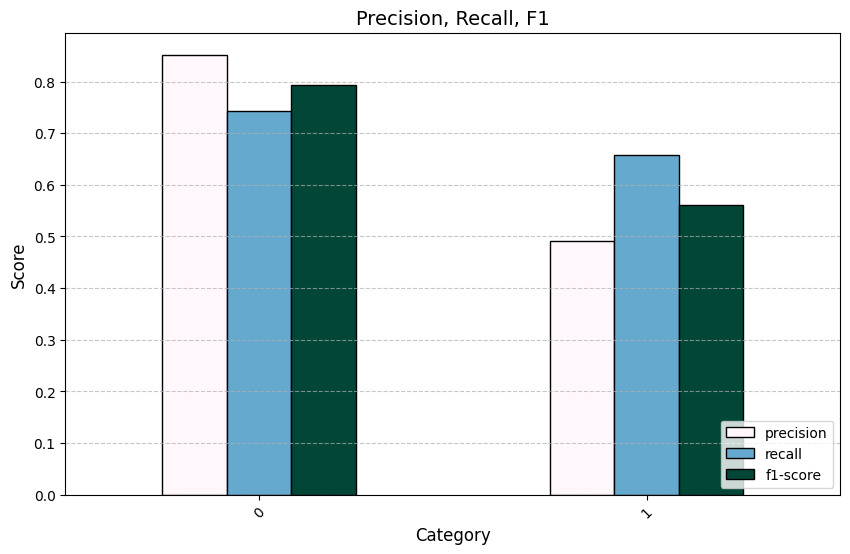

<Figure size 640x480 with 0 Axes>

In [3]:
#SVM MODEL - vectorized input
target_names = [str(t) for t in sorted(y_train.unique())]
svm_model = train_SVM(X_train, y_train, X_test, y_test, target_names, boost_factor = 2.0)

# input - sparse matrix (riadka matica) - only non-zero values are stored


RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (555, 3000)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 3000
Matrix Format: <class 'scipy.sparse._csr.csr_matrix'>
------------------------------
First sample (first 10 TF-IDF feature values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
------------------------------
Original class weights: [0.68688119 1.83774834]
Boosted class weights: [0.68688119 5.51324503]
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Random Forest parameters found via StratifiedKFold: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0     0.8298    0.7723    0.8000       101
           1     0.4889    0.5789    0.5301        38

    accuracy                         0.7194       139
   macro avg     0.659

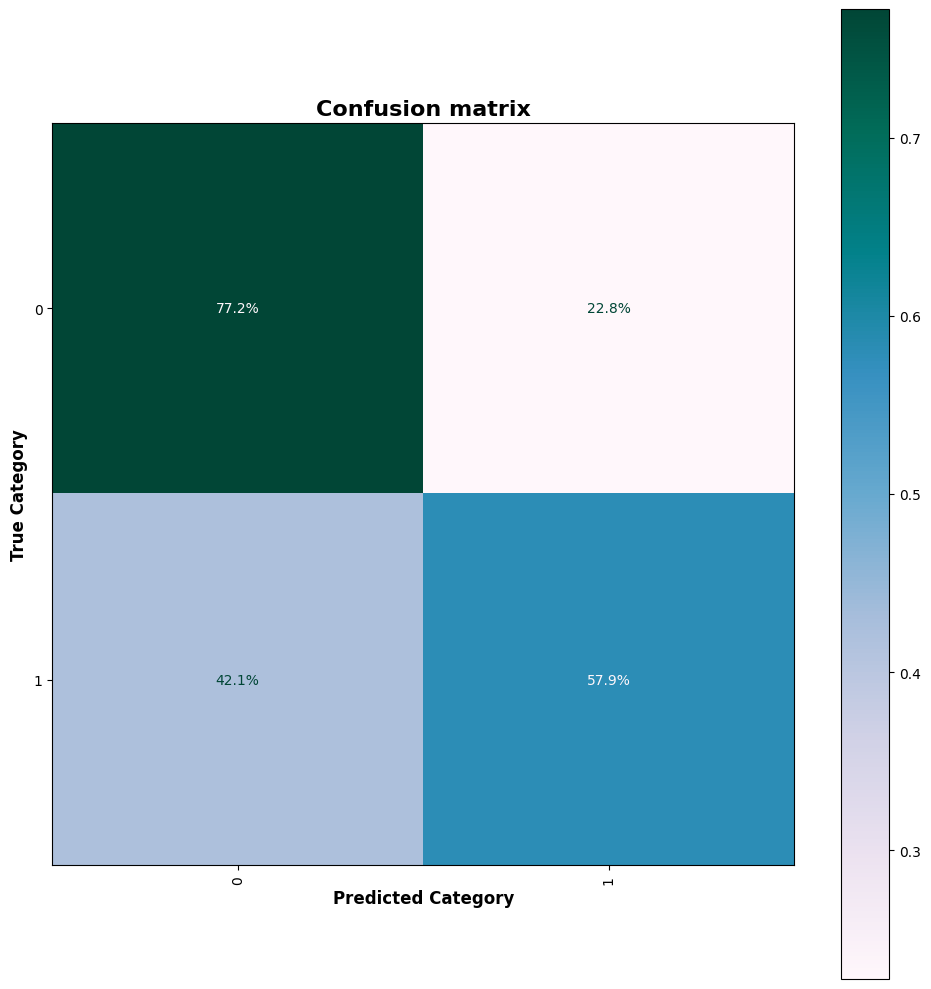

<Figure size 640x480 with 0 Axes>

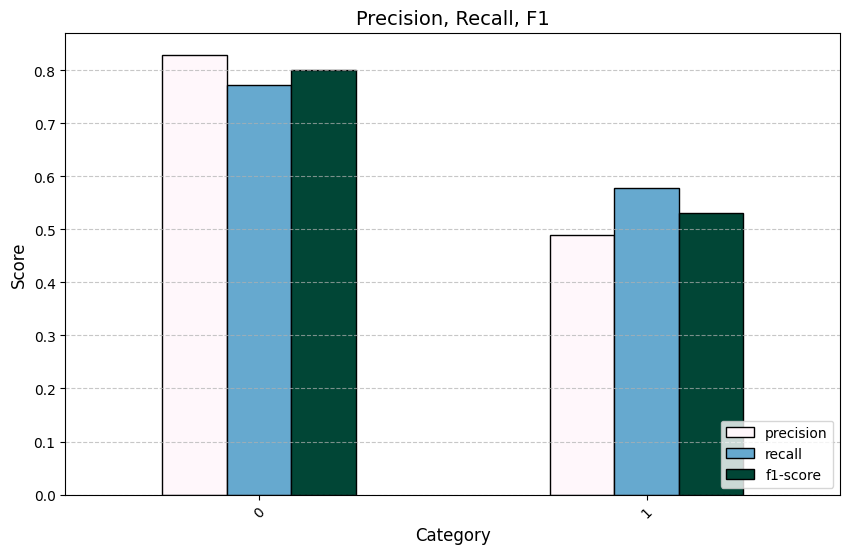

<Figure size 640x480 with 0 Axes>

In [4]:
#RANDOM FOREST - vectorized input
rf_model = train_random_forest(X_train, y_train, X_test, y_test, target_names, boost_factor = 3.0)

# input - sparse matrix (riadka matica) - only non-zero values are stored